In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
new_df = df.drop(columns=['Cabin', 'Ticket', 'Name'])

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
new_df['Sex'] = new_df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
new_df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
sns.heatmap(new_df.corr(), cmap="YlGnBu")
plt.show()

ValueError: could not convert string to float: 'S'

above, higher correlation between gender and survival is seen (where 1 is female and 0 is male) and for Embarked it would be as C is 0, Q is 1, S is 2 (last part was discarded for one hot encoder)

In [ ]:
age_m50 = df.loc[df.Age > 50][df.Survived == 1]
cm50 = len(df.loc[df.Age > 50])

age_l50 = df.loc[df.Age <= 50][df.Survived == 1]
cl50 = len(df.loc[df.Age <= 50])
print(f'age more than 50: {len(age_m50)}')
print(f'age less than 50 or equal: {len(age_l50)}')

print(f'% of survival above 50: {len(age_m50)/cm50*100}%')
print(f'% of survival below 50: {len(age_l50)/cl50*100}%')


age more than 50: 22
age less than 50 or equal: 268
% of survival above 50: 34.375%
% of survival below 50: 41.23076923076923%


/tmp/ipython-input-863250513.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_m50 = df.loc[df.Age > 50][df.Survived == 1]
/tmp/ipython-input-863250513.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_l50 = df.loc[df.Age <= 50][df.Survived == 1]


In [ ]:
sib = df.loc[df.SibSp == 1][df.Survived == 1]
surv = len(df.loc[df.Survived == 1])

par = df.loc[df.Parch == 1][df.Survived == 1]


print(f'% of survival with siblings: {len(sib)/surv*100}%')
print(f'% of survival with parents: {len(par)/surv*100}%')

% of survival with siblings: 32.748538011695906%
% of survival with parents: 19.005847953216374%


/tmp/ipython-input-1485132213.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sib = df.loc[df.SibSp == 1][df.Survived == 1]
/tmp/ipython-input-1485132213.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  par = df.loc[df.Parch == 1][df.Survived == 1]


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for training_indices, test_indices in split.split(new_df, new_df[["Survived", "Pclass", "Sex"]]):
    strat_train_set = new_df.loc[training_indices]
    strat_test_set = new_df.loc[test_indices]

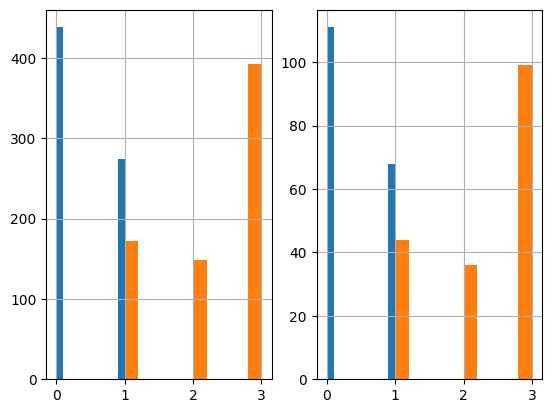

In [ ]:
plt.subplot(1,2,1)
strat_train_set.Survived.hist()
strat_train_set.Pclass.hist()

plt.subplot(1,2,2)
strat_test_set.Survived.hist()
strat_test_set.Pclass.hist()

plt.show()

In [ ]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 462 to 217
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Sex          712 non-null    object 
 4   Age          568 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Fare         712 non-null    float64
 8   Embarked     710 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 55.6+ KB


In [ ]:
#to fill age
from sklearn.base import BaseEstimator
from sklearn.impute import SimpleImputer
from sklearn.base import TransformerMixin


class AgeImputer(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    imputer = SimpleImputer(strategy="mean")
    X["Age"] = imputer.fit_transform(X[["Age"]])
    return X

In [ ]:

from sklearn.preprocessing import OneHotEncoder


class FeatureEncoder(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    encoder = OneHotEncoder()
    matrix = encoder.fit_transform(X[["Embarked"]]).toarray()

    column_names = ["C", "S", "Q", "N"]

    for i in range(len(matrix.T)):
      X[column_names[i]] = matrix.T[i]

    matrix = encoder.fit_transform(X[["Sex"]]).toarray()

    column_names = ["Female", "Male"]

    for i in range(len(matrix.T)):
      X[column_names[i]] = matrix.T[i]

    return X

In [ ]:
class FeatureDropper(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    return self

  def transform(self, X):
    return X.drop(columns=["Embarked", "Name", "Ticket", "Cabin", "Sex", "N"], axis = 1, errors = "ignore")

In [ ]:
from sklearn .pipeline import Pipeline

pipline = Pipeline([("ageimputer", AgeImputer()), ("featureencoder", FeatureEncoder()), ("featuredropper", FeatureDropper())])

In [ ]:
strat_train_set = pipline.fit_transform(strat_train_set)

In [ ]:
strat_train_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
462,463,0,1,47.000000,0,0,38.5000,0.0,0.0,1.0,0.0,1.0
436,437,0,3,21.000000,2,2,34.3750,0.0,0.0,1.0,1.0,0.0
169,170,0,3,28.000000,0,0,56.4958,0.0,0.0,1.0,0.0,1.0
26,27,0,3,29.853592,0,0,7.2250,1.0,0.0,0.0,0.0,1.0
190,191,1,2,32.000000,0,0,13.0000,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14,15,0,3,14.000000,0,0,7.8542,0.0,0.0,1.0,1.0,0.0
17,18,1,2,29.853592,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
101,102,0,3,29.853592,0,0,7.8958,0.0,0.0,1.0,0.0,1.0
721,722,0,3,17.000000,1,0,7.0542,0.0,0.0,1.0,0.0,1.0


In [ ]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 462 to 217
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  Female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB


In [ ]:
from sklearn.preprocessing import StandardScaler

X = strat_train_set.drop("Survived", axis = 1)
y = strat_train_set["Survived"]

scaler = StandardScaler()
X_data = scaler.fit_transform(X)
y_data = y.to_numpy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier()

parameter_grid = [
    {"n_estimators": [10, 100, 200, 500], "max_depth": [None, 5, 10], "min_samples_split": [2, 3, 4]}
]

grid_search = GridSearchCV(clf, parameter_grid, cv = 3, scoring = "accuracy", return_train_score = True)
grid_search.fit(X_data, y_data)

GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [ ]:
final_clf = grid_search.best_estimator_

In [ ]:
strat_test_set = pipline.fit_transform(strat_test_set)

In [ ]:
X_test = strat_test_set.drop("Survived", axis = 1)
y_test = strat_test_set["Survived"]

scaler = StandardScaler()
X_data_test = scaler.fit_transform(X_test)
y_data_test = y_test.to_numpy()

In [ ]:
final_clf.score(X_data_test, y_data_test)

0.8100558659217877

In [ ]:
combined = pipline.fit_transform(new_df)

In [ ]:
combined

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
0,1,0,3,22.000000,1,0,7.2500,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.000000,1,0,71.2833,1.0,0.0,0.0,1.0,0.0
2,3,1,3,26.000000,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.000000,1,0,53.1000,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.000000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
887,888,1,1,19.000000,0,0,30.0000,0.0,0.0,1.0,1.0,0.0
888,889,0,3,29.699118,1,2,23.4500,0.0,0.0,1.0,1.0,0.0
889,890,1,1,26.000000,0,0,30.0000,1.0,0.0,0.0,0.0,1.0


In [ ]:
X_final = combined.drop("Survived", axis = 1)
y_final = combined["Survived"]

scaler = StandardScaler()
X_data_final = scaler.fit_transform(X_final)
y_data_final = y_final.to_numpy()

In [ ]:
prod_clf = RandomForestClassifier()
parameters_grid2 = [
    {"n_estimators": [10, 100, 200, 500], "max_depth": [None, 5, 10], "min_samples_split": [2, 3, 4]}
]

grid_search2 = GridSearchCV(prod_clf, parameters_grid2, cv = 3, scoring = "accuracy", return_train_score = True)
grid_search2.fit(X_data_final, y_data_final)


GridSearchCV(cv=3, estimator=RandomForestClassifier(),
             param_grid=[{'max_depth': [None, 5, 10],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 100, 200, 500]}],
             return_train_score=True, scoring='accuracy')

In [ ]:
prod_final_clf = grid_search2.best_estimator_

In [ ]:
prod_final_clf

RandomForestClassifier(max_depth=5, n_estimators=500)

In [ ]:
df_test = pd.read_csv('test.csv')

In [ ]:
final_test_data = pipline.fit_transform(df_test)

In [ ]:
X_final_test = final_test_data
X_final_test = X_final_test.fillna(method="ffill")

scaler = StandardScaler()
X_data_final_test = scaler.fit_transform(X_final_test)

/tmp/ipython-input-1896703401.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_final_test = X_final_test.fillna(method="ffill")


In [ ]:
predictions = prod_final_clf.predict(X_data_final_test)

In [ ]:
final_df = pd.DataFrame(df_test['PassengerId'])
final_df['Survived'] = predictions
final_df.to_csv('submission.csv', index=False)

In [ ]:
final_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
